In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
try:
    from wordcloud import WordCloud
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud"])
    from wordcloud import WordCloud

In [22]:
def find_project_root(start_path: Path) -> Path:
    start_path = start_path.resolve()

    for path in [start_path] + list(start_path.parents):
        if (path / "requirements.txt").exists() and (path / "data").exists():
            return path

    return start_path


PROJECT_ROOT = find_project_root(Path.cwd())

CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_news.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cleaned dataset path:", CLEANED_DATA_PATH)
print("Figures folder:", FIGURES_DIR)

Project root: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector
Cleaned dataset path: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\data\processed\cleaned_news.csv
Figures folder: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\reports\figures


In [23]:
def find_project_root(start_path: Path) -> Path:
    start_path = start_path.resolve()

    for path in [start_path] + list(start_path.parents):
        if (path / "requirements.txt").exists() and (path / "data").exists():
            return path

    return start_path


PROJECT_ROOT = find_project_root(Path.cwd())

CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_news.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cleaned dataset path:", CLEANED_DATA_PATH)
print("Figures folder:", FIGURES_DIR)

Project root: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector
Cleaned dataset path: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\data\processed\cleaned_news.csv
Figures folder: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\reports\figures


In [24]:
data = pd.read_csv(CLEANED_DATA_PATH)

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns)

display(data.head())

Dataset shape: (39098, 3)

Columns:
Index(['content', 'clean_text', 'label'], dtype='str')


,content,clean_text,label
0,Donald Trump Sends Out Embarrassing New Year’s...,donald trump sends embarrassing new year eve m...,0
1,Drunk Bragging Trump Staffer Started Russian C...,drunk bragging trump staffer started russian c...,0
2,Sheriff David Clarke Becomes An Internet Joke ...,sheriff david clarke becomes internet joke thr...,0
3,Trump Is So Obsessed He Even Has Obama’s Name ...,trump obsessed even obama name coded website i...,0
4,Pope Francis Just Called Out Donald Trump Duri...,pope francis called donald trump christmas spe...,0


In [25]:
print("Missing values:")
print(data.isnull().sum())

print("\nClass distribution:")
print(data["label"].value_counts())

print("\nClass distribution percentage:")
print(data["label"].value_counts(normalize=True) * 100)

Missing values:
content       0
clean_text    0
label         0
dtype: int64

Class distribution:
label
1    21196
0    17902
Name: count, dtype: int64

Class distribution percentage:
label
1    54.212492
0    45.787508
Name: proportion, dtype: float64


In [26]:
data["label_name"] = data["label"].map({
    0: "Fake News",
    1: "Real News"
})

display(data[["clean_text", "label", "label_name"]].head())

,clean_text,label,label_name
0,donald trump sends embarrassing new year eve m...,0,Fake News
1,drunk bragging trump staffer started russian c...,0,Fake News
2,sheriff david clarke becomes internet joke thr...,0,Fake News
3,trump obsessed even obama name coded website i...,0,Fake News
4,pope francis called donald trump christmas spe...,0,Fake News


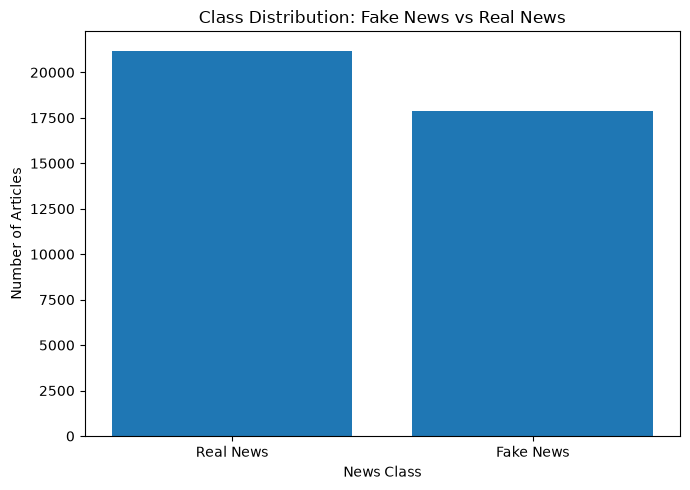

In [27]:
class_counts = data["label_name"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution: Fake News vs Real News")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "class_distribution.png")
plt.show()

In [28]:
data["word_count"] = data["clean_text"].astype(str).apply(lambda x: len(x.split()))
data["char_count"] = data["clean_text"].astype(str).apply(len)

display(data[["clean_text", "word_count", "char_count", "label_name"]].head())

print("Word count statistics:")
display(data.groupby("label_name")["word_count"].describe())

,clean_text,word_count,char_count,label_name
0,donald trump sends embarrassing new year eve m...,273,1852,Fake News
1,drunk bragging trump staffer started russian c...,185,1410,Fake News
2,sheriff david clarke becomes internet joke thr...,346,2404,Fake News
3,trump obsessed even obama name coded website i...,263,1819,Fake News
4,pope francis called donald trump christmas spe...,215,1464,Fake News


Word count statistics:


,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Fake News,17902.0,236.937214,201.062288,3.0,155.0,212.0,281.75,4910.0
Real News,21196.0,232.670598,158.130625,4.0,94.0,217.0,312.00,2342.0


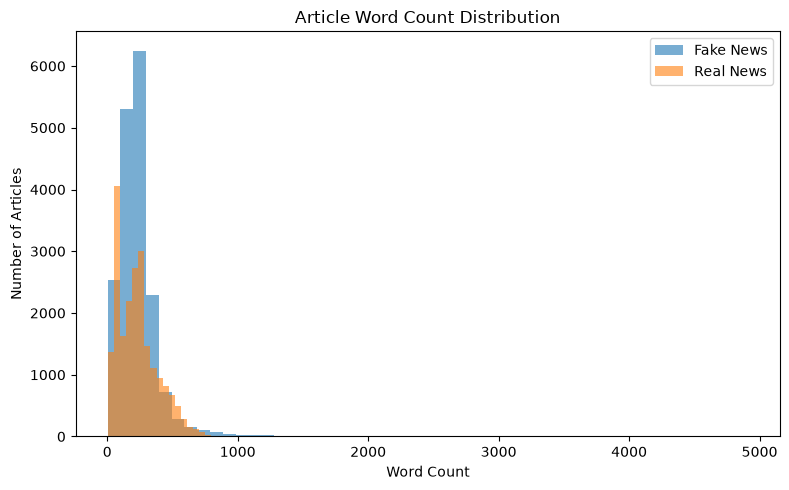

In [29]:
fake_word_counts = data[data["label"] == 0]["word_count"]
real_word_counts = data[data["label"] == 1]["word_count"]

plt.figure(figsize=(8, 5))
plt.hist(fake_word_counts, bins=50, alpha=0.6, label="Fake News")
plt.hist(real_word_counts, bins=50, alpha=0.6, label="Real News")
plt.title("Article Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Articles")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "word_count_distribution.png")
plt.show()

In [30]:
def get_top_words(text_series, top_n=20):
    all_words = " ".join(text_series.astype(str)).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(top_n)

In [31]:
fake_text = data[data["label"] == 0]["clean_text"]
top_fake_words = get_top_words(fake_text, top_n=20)

fake_words_df = pd.DataFrame(top_fake_words, columns=["word", "count"])
display(fake_words_df)

,word,count
0,trump,76575
1,said,24958
2,president,22170
3,people,21674
4,one,20081
5,would,18457
6,state,17497
7,donald,16145
8,republican,15483
9,like,15167


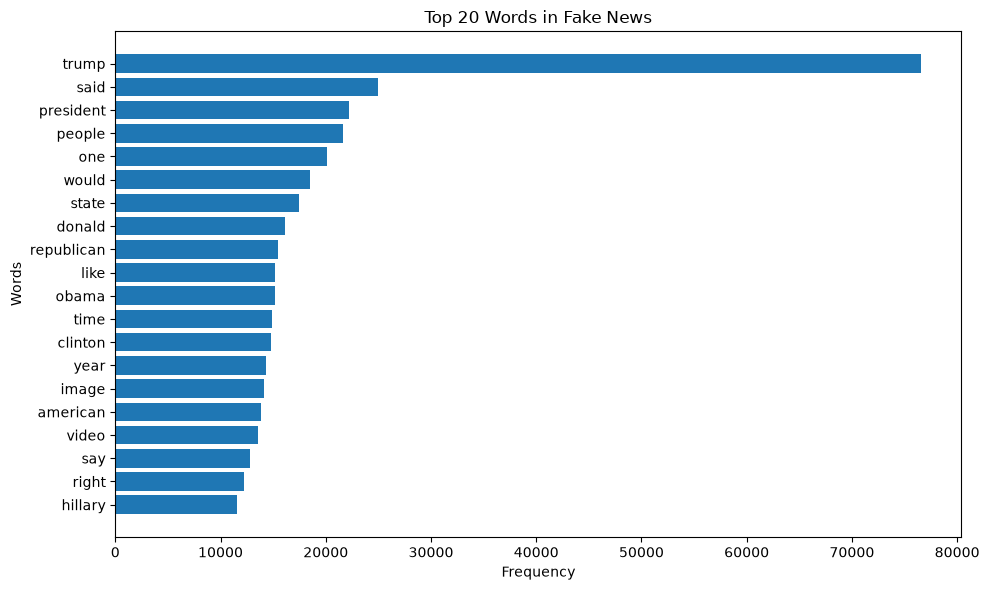

In [32]:
plt.figure(figsize=(10, 6))
plt.barh(fake_words_df["word"], fake_words_df["count"])
plt.title("Top 20 Words in Fake News")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_words_fake_news.png")
plt.show()

In [33]:
real_text = data[data["label"] == 1]["clean_text"]
top_real_words = get_top_words(real_text, top_n=20)

real_words_df = pd.DataFrame(top_real_words, columns=["word", "count"])
display(real_words_df)

,word,count
0,said,97844
1,trump,59618
2,state,38034
3,would,31471
4,president,28919
5,reuters,28781
6,republican,23826
7,year,22599
8,government,20096
9,house,18316


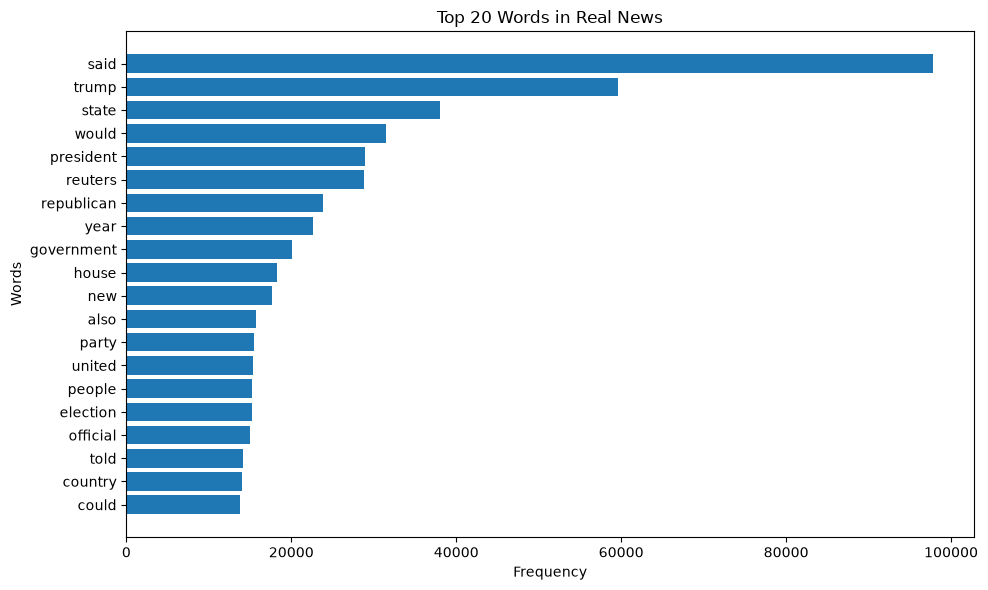

In [34]:
plt.figure(figsize=(10, 6))
plt.barh(real_words_df["word"], real_words_df["count"])
plt.title("Top 20 Words in Real News")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_words_real_news.png")
plt.show()

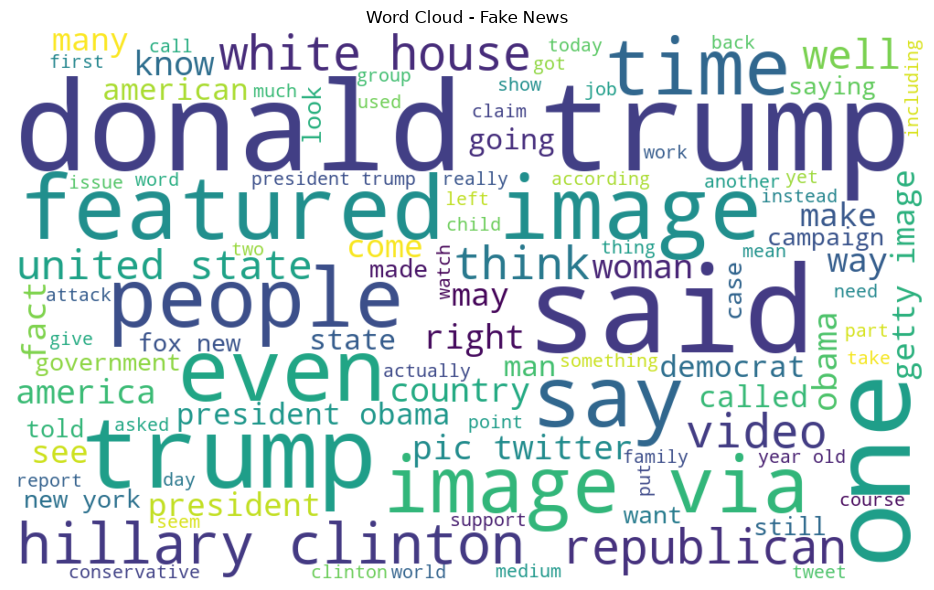

In [35]:
fake_text_combined = " ".join(fake_text.astype(str))

fake_wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=100
).generate(fake_text_combined)

plt.figure(figsize=(10, 6))
plt.imshow(fake_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Fake News")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "fake_news_wordcloud.png")
plt.show()

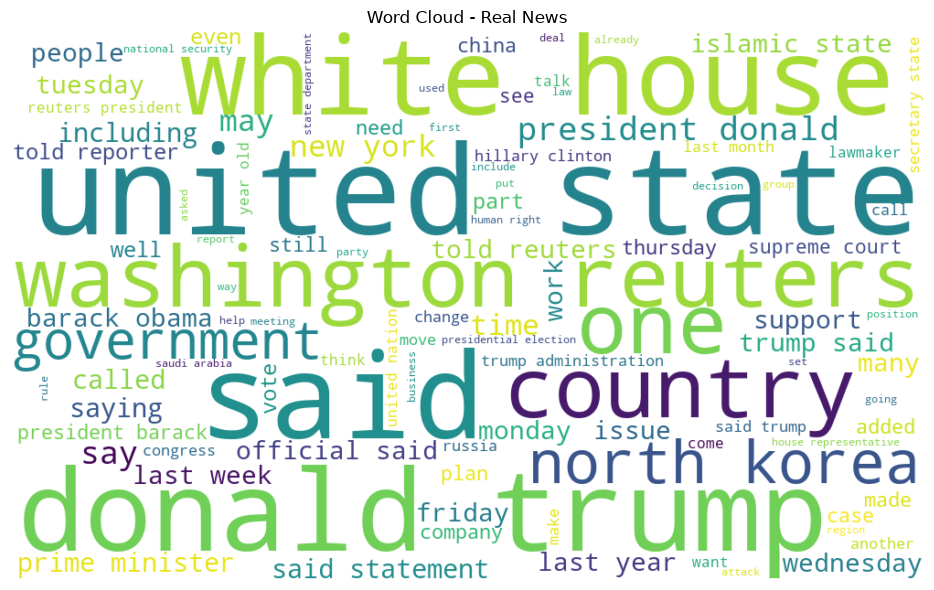

In [36]:
real_text_combined = " ".join(real_text.astype(str))

real_wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=100
).generate(real_text_combined)

plt.figure(figsize=(10, 6))
plt.imshow(real_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Real News")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "real_news_wordcloud.png")
plt.show()

In [37]:
summary = {
    "total_records": len(data),
    "fake_news_count": int((data["label"] == 0).sum()),
    "real_news_count": int((data["label"] == 1).sum()),
    "average_word_count": float(data["word_count"].mean()),
    "average_fake_word_count": float(data[data["label"] == 0]["word_count"].mean()),
    "average_real_word_count": float(data[data["label"] == 1]["word_count"].mean())
}

summary_df = pd.DataFrame([summary])

METRICS_DIR = PROJECT_ROOT / "reports" / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

summary_path = METRICS_DIR / "eda_summary.csv"
summary_df.to_csv(summary_path, index=False)

display(summary_df)

print("EDA summary saved to:", summary_path)

,total_records,fake_news_count,real_news_count,average_word_count,average_fake_word_count,average_real_word_count
0,39098,17902,21196,234.624175,236.937214,232.670598


EDA summary saved to: C:\Users\user\Documents\fake news detection 0.1\FakeNewsDetector\reports\metrics\eda_summary.csv


In [38]:
print("EDA Insights:")
print("1. The class distribution shows whether the dataset is balanced or imbalanced.")
print("2. Word count analysis helps identify the average length of fake and real news articles.")
print("3. Top-word analysis shows frequently used terms in fake and real news.")
print("4. Word clouds provide a visual summary of dominant words in each class.")
print("5. These observations help understand dataset quality before model training.")

EDA Insights:
1. The class distribution shows whether the dataset is balanced or imbalanced.
2. Word count analysis helps identify the average length of fake and real news articles.
3. Top-word analysis shows frequently used terms in fake and real news.
4. Word clouds provide a visual summary of dominant words in each class.
5. These observations help understand dataset quality before model training.
